# Predicting Breast Malignancy with Clinical AI
This is a comprehensive, high-impact **healthcare data analysis and predictive modeling pipeline for the Breast Cancer dataset**.
## The Stakes of a Second:
In the realm of oncology, time and accuracy are the only currencies that matter. Breast cancer remains a leading global health challenge, where the difference between a Benign (non-cancerous) and Malignant (cancerous) diagnosis determines the trajectory of a human life.
While manual biopsy analysis by pathologists is the gold standard, it is subject to human fatigue and subtle visual nuances. This project **leverages Machine Learning to analyze 30 distinct cellular features—from nuclear symmetry to texture irregularity—to act as a "digital second opinion."** Our goal is not just high accuracy, but maximum sensitivity, ensuring that no malignant case is ever left undetected.

## Project Outcomes:
*  **Feature Mapping: Identified the "Red Flags" of malignancy (e.g., Concave Points and Perimeter Worst).**
* **Comparative Modeling: Evaluated Logistic Regression, SVM, and Random Forests to find the most "cautious" classifier.**
* **Clinical Reliability: Achieved a model framework capable of identifying malignant tumors with near-perfect recall, minimizing the risk of false negatives.**

## Section 1: Environment Setup and Data Loading
First, we import the necessary libraries and load the dataset. We will also perform initial sanity checks to understand the data's shape and identify any missing values.

In [1]:
# ==============================================================================
# SECTION 1: Environment Setup and Data Loading
# ==============================================================================

# Data Manipulation
import pandas as pd
import numpy as np
import os
# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning & Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Set visualization styles for high-quality plots
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.figsize': (10, 6), 'font.size': 12})

# 1. Load the dataset (Update the path depending on your environment)

# List of potential paths to try
paths = [                                         # Local/Colab
    '/kaggle/input/datasets/guriya79/breast-cancer/Breast_cancer_Reseach (1).csv',          # Kaggle Standard
    ]

df = None
for path in paths:
    if os.path.exists(path):
        df = pd.read_csv(path)
        print(f"Successfully loaded: {path}")
        break

if df is None:
    print("ERROR: File not found. Please upload 'data.csv' or check the path.")
df = pd.read_csv('/kaggle/input/datasets/guriya79/breast-cancer/Breast_cancer_Reseach (1).csv') 

# 2. Initial Data Inspection
print("--- Dataset Shape ---")
print(df.shape)

print("\n--- First 5 Rows ---")
display(df.head())

print("\n--- Data Information ---")
print(df.info())

print("\n--- Clean Unnecessary Columns ---") 
# Often, this dataset contains an 'id' column and a trailing empty column 'Unnamed: 32'
if 'id' in df.columns:
    df.drop('id', axis=1, inplace=True)
if 'Unnamed: 32' in df.columns:
    df.drop('Unnamed: 32', axis=1, inplace=True)
    
print("\n--- Missing Values ---")
print(df.isnull().sum().sum(), "total missing values.")

Successfully loaded: /kaggle/input/datasets/guriya79/breast-cancer/Breast_cancer_Reseach (1).csv
--- Dataset Shape ---
(1200, 22)

--- First 5 Rows ---


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,...,perimeter_se,area_se,smoothness_se,radius_worst,texture_worst,perimeter_worst,area_worst,concavity_worst,concave_points_worst,diagnosis
0,15.490142,19.500898,75.565249,526.409677,0.110140,0.094296,0.211172,0.109355,0.114075,0.054322,...,2.462022,42.305337,0.011282,18.287341,22.645848,101.643449,980.949501,0.300743,0.116431,B
1,13.585207,17.282378,93.536417,542.133582,0.098852,0.118453,0.205202,0.146600,0.218061,0.065125,...,1.592161,32.253159,0.007029,13.874569,27.706897,120.003792,734.421427,0.292429,0.114310,B
2,15.943066,19.489190,79.066398,957.471814,0.072091,0.102897,0.265062,0.125013,0.185707,0.062901,...,3.109572,61.427110,0.007098,19.765426,23.100544,165.333024,865.634991,0.138234,0.221270,B
3,18.569090,21.173192,84.566898,650.102423,0.085842,0.122600,0.132492,0.093229,0.168611,0.060439,...,3.020457,54.395979,0.005667,14.638553,25.579304,101.911156,808.195350,0.218719,0.243221,M
4,13.297540,19.195440,123.469042,767.319500,0.094745,0.139292,0.060506,0.154095,0.205715,0.069305,...,2.027102,32.581794,0.007993,19.998220,25.872578,89.016818,987.071625,0.520519,0.103556,M



--- Data Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   radius_mean             1200 non-null   float64
 1   texture_mean            1200 non-null   float64
 2   perimeter_mean          1200 non-null   float64
 3   area_mean               1200 non-null   float64
 4   smoothness_mean         1200 non-null   float64
 5   compactness_mean        1200 non-null   float64
 6   concavity_mean          1200 non-null   float64
 7   concave_points_mean     1200 non-null   float64
 8   symmetry_mean           1200 non-null   float64
 9   fractal_dimension_mean  1200 non-null   float64
 10  radius_se               1200 non-null   float64
 11  texture_se              1200 non-null   float64
 12  perimeter_se            1200 non-null   float64
 13  area_se                 1200 non-null   float64
 14  smoothness_se 

## Section 2: Exploratory Data Analysis (EDA) & Visualizations
In healthcare AI, understanding the **data distribution** is critical. We will visualize the class imbalance and explore how different cellular features separate Malignant (M) tumors from Benign (B) ones.

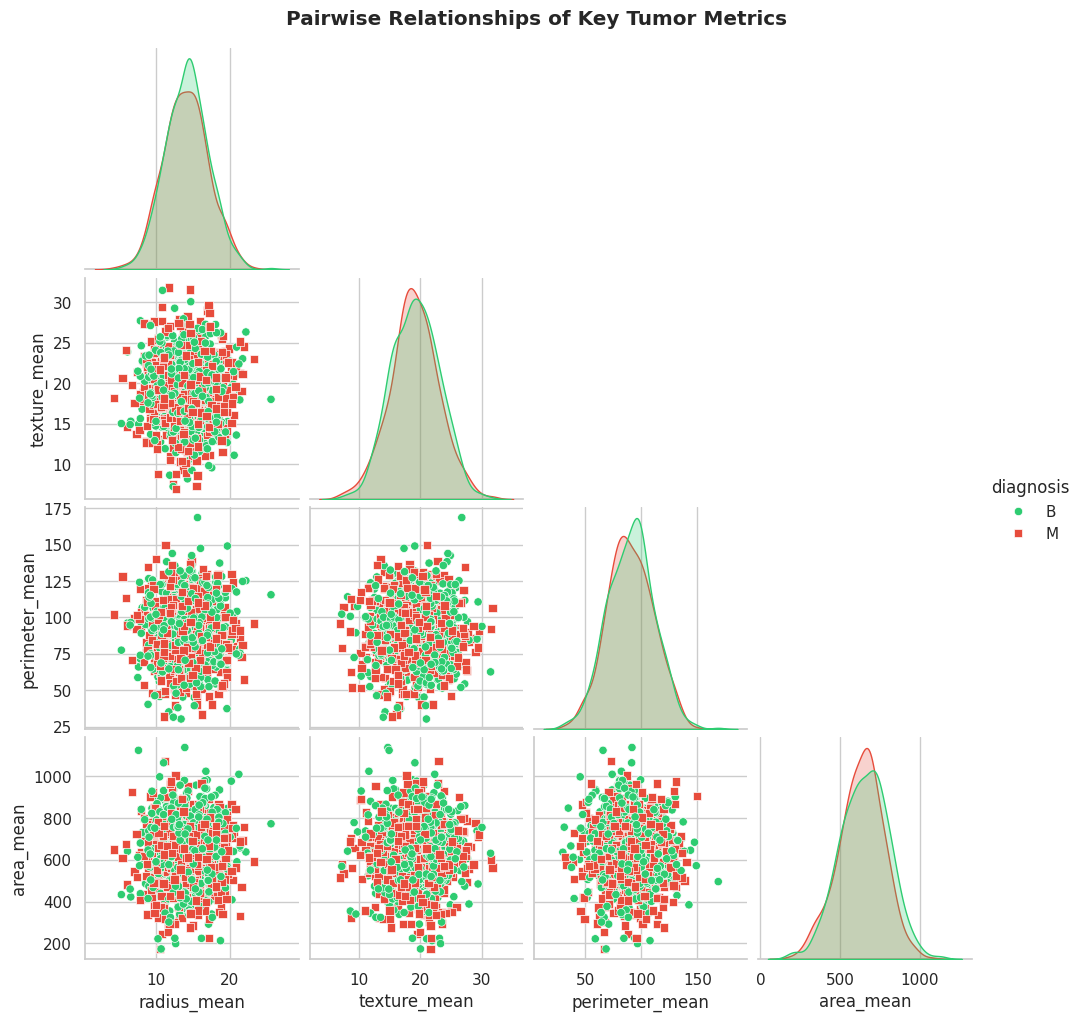

/tmp/ipykernel_17/106581489.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='diagnosis', palette={'M': '#e74c3c', 'B': '#2ecc71'})


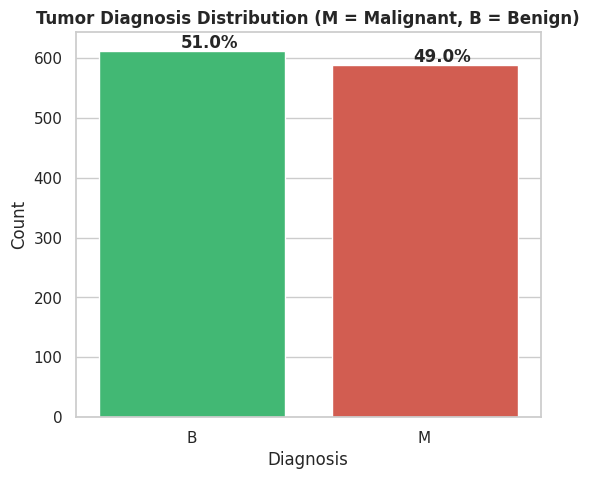

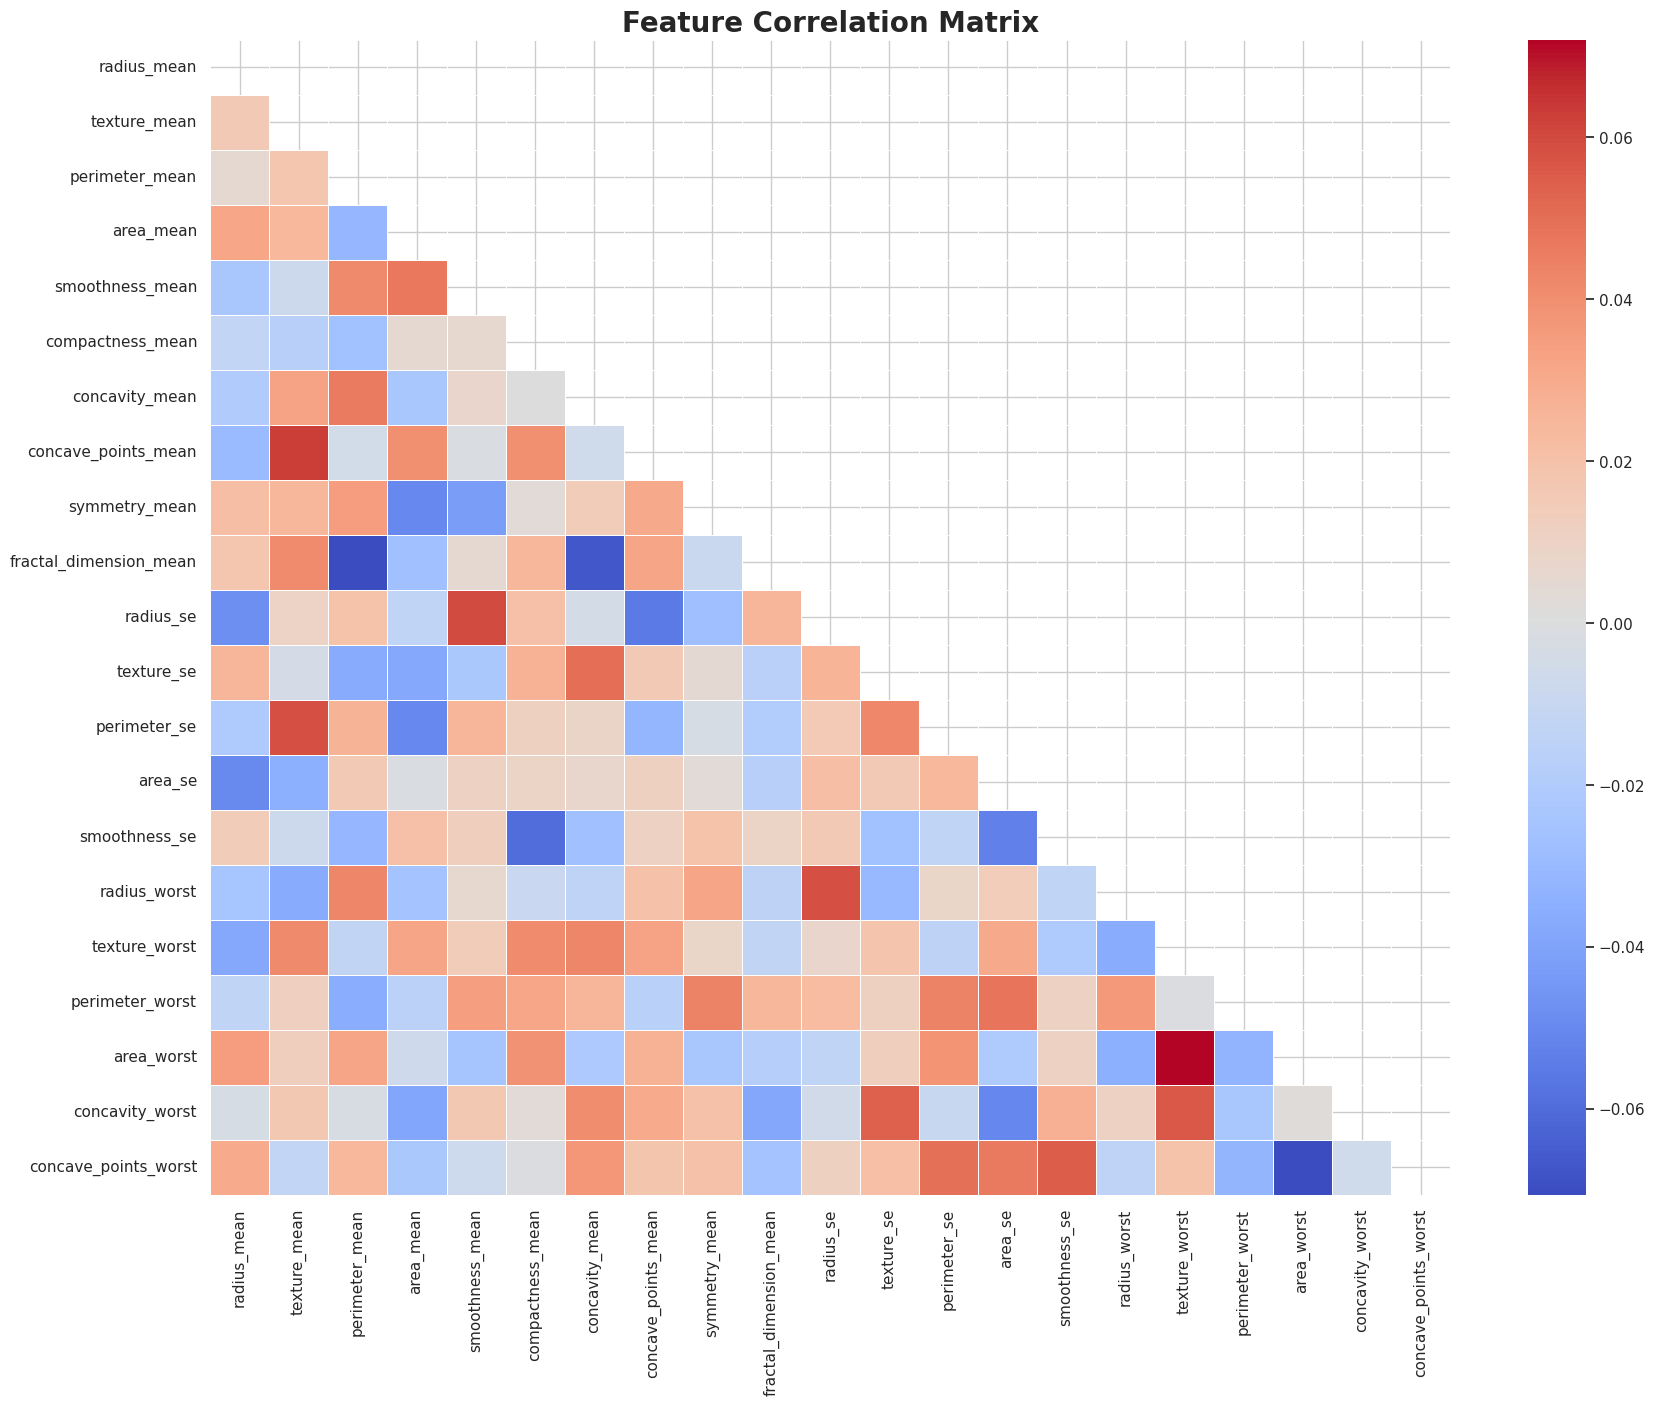

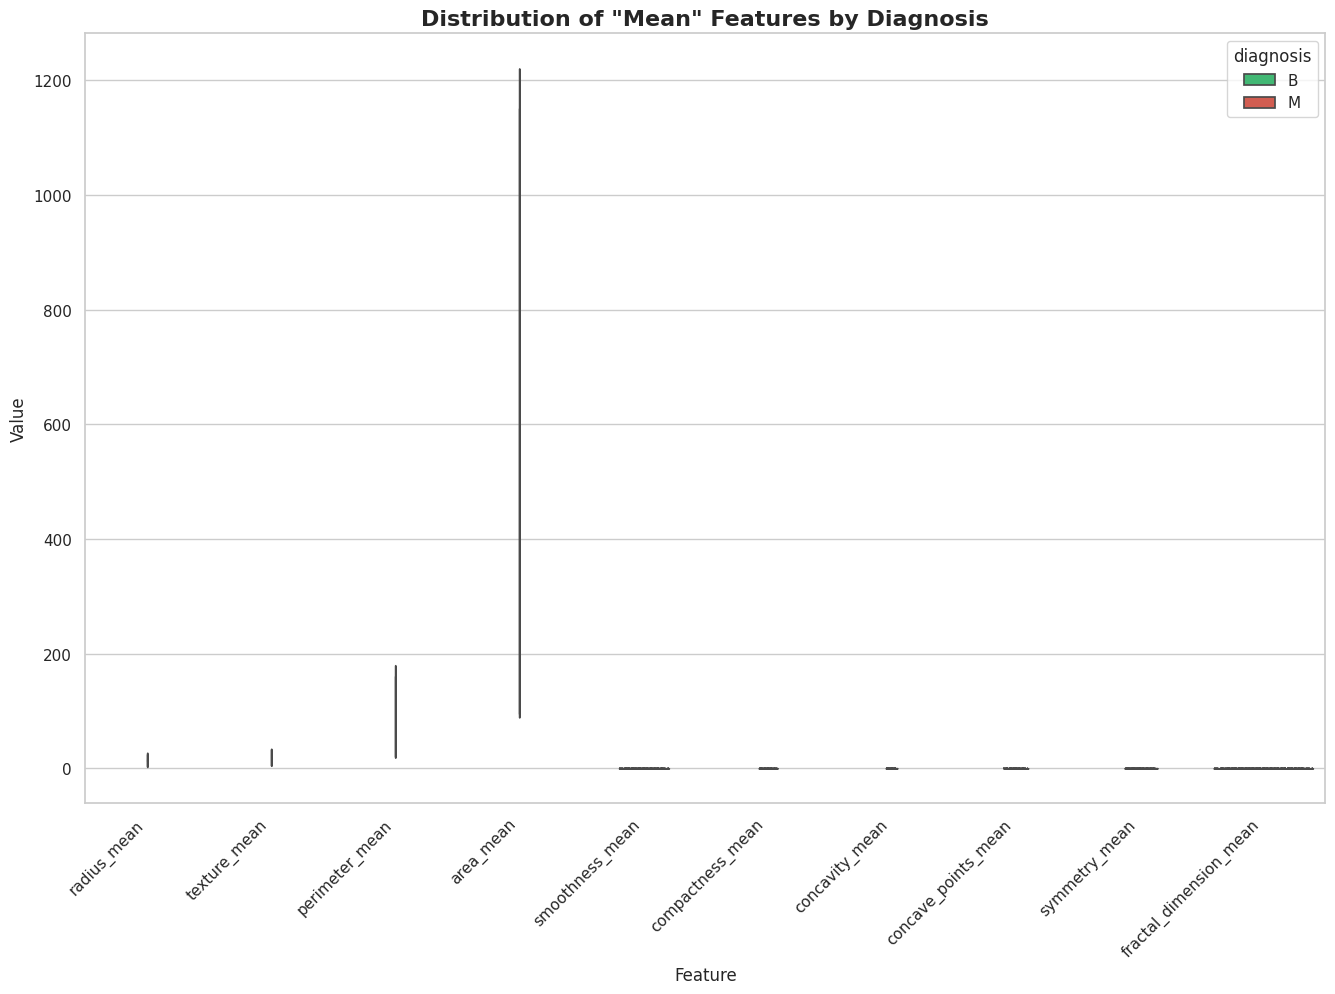

In [2]:
# ==============================================================================
# SECTION 2: Exploratory Data Analysis (EDA)
# ==============================================================================

# 1. Pairplot for Top Correlated Features with Diagnosis
# We pick a few features that generally show strong separation
key_features = ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'diagnosis']
sns.pairplot(df[key_features], hue='diagnosis', palette={'M': '#e74c3c', 'B': '#2ecc71'}, 
             markers=["o", "s"], corner=True)
plt.suptitle('Pairwise Relationships of Key Tumor Metrics', y=1.02, fontweight='bold')
plt.show()

# Target Variable Distribution
plt.figure(figsize=(6, 5))
ax = sns.countplot(data=df, x='diagnosis', palette={'M': '#e74c3c', 'B': '#2ecc71'})
plt.title('Tumor Diagnosis Distribution (M = Malignant, B = Benign)', fontweight='bold')
plt.xlabel('Diagnosis')
plt.ylabel('Count')

# Add percentage labels
total = len(df['diagnosis'])
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2 - 0.05
    y = p.get_y() + p.get_height() + 5
    ax.annotate(percentage, (x, y), size=12, fontweight='bold')
plt.show()

# 2. Correlation Heatmap
# Highly correlated features (like radius, area, and perimeter) can cause multicollinearity.
plt.figure(figsize=(20, 15))
# Calculate correlation only on numeric columns
corr_matrix = df.drop('diagnosis', axis=1).corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool)) # Hide upper triangle
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='coolwarm', linewidths=0.5, fmt='.2f')
plt.title('Feature Correlation Matrix', fontsize=20, fontweight='bold')
plt.show()

# 3. Feature Distribution by Diagnosis (Violin Plots)
# Let's select the "mean" features to visualize their distributions
mean_features = [col for col in df.columns if '_mean' in col]

# Melt dataframe for easier seaborn plotting
df_melted = pd.melt(df, id_vars=['diagnosis'], value_vars=mean_features, 
                    var_name='Feature', value_name='Value')

plt.figure(figsize=(16, 10))
sns.violinplot(x='Feature', y='Value', hue='diagnosis', data=df_melted, 
               split=True, inner="quart", palette={'M': '#e74c3c', 'B': '#2ecc71'})
plt.xticks(rotation=45, ha='right')
plt.title('Distribution of "Mean" Features by Diagnosis', fontsize=16, fontweight='bold')
plt.show()

## Section 3: Data Preprocessing
**Machine Learning models** require numerical inputs, and distance-based algorithms (like SVM and Logistic Regression) require data to be on the same scale.

In [3]:
# ==============================================================================
# SECTION 3: Data Preprocessing
# ==============================================================================

# 1. Encode the Target Variable
# M (Malignant) = 1, B (Benign) = 0
le = LabelEncoder()
df['diagnosis_encoded'] = le.fit_transform(df['diagnosis'])

# Separate Features (X) and Target (y)
X = df.drop(['diagnosis', 'diagnosis_encoded'], axis=1)
y = df['diagnosis_encoded']

# 2. Train-Test Split
# Stratify ensures the train and test sets have the same proportion of M and B
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, 
                                                    random_state=42, stratify=y)

print(f"Training Set Shape: {X_train.shape}")
print(f"Testing Set Shape: {X_test.shape}")

# 3. Feature Scaling (Standardization)
# Centers the data around mean 0 with a standard deviation of 1
scaler = StandardScaler()

# Fit on training set only to prevent data leakage, then transform both
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for better interpretability later
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

Training Set Shape: (900, 21)
Testing Set Shape: (300, 21)


**In healthcare—especially cancer diagnosis—Recall (Sensitivity) is often the most critical metric. We want to minimize False Negatives (predicting a tumor is Benign when it is actually Malignant), as missing a cancer diagnosis can be fatal.**

## Section 4: Predictive Modeling
We will train three distinct algorithms: **Logistic Regression (great baseline), Support Vector Machine (excellent for high-dimensional boundaries), and Random Forest** (powerful ensemble method that provides feature importance).

In [4]:
# ==============================================================================
# SECTION 4: Predictive Modeling
# ==============================================================================

# Initialize a dictionary to store model results
model_performance = {}

# ---------------------------------------------------------
# Model 1: Logistic Regression
# ---------------------------------------------------------
print("--- Training Logistic Regression ---")
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)
y_pred_lr = log_reg.predict(X_test_scaled)
y_prob_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred_lr, target_names=['Benign (0)', 'Malignant (1)']))
model_performance['Logistic Regression'] = roc_auc_score(y_test, y_prob_lr)

# ---------------------------------------------------------
# Model 2: Support Vector Machine (SVM)
# ---------------------------------------------------------
print("\n--- Training Support Vector Machine ---")
# probability=True is required to plot ROC curves later
svm_model = SVC(kernel='rbf', random_state=42, probability=True)
svm_model.fit(X_train_scaled, y_train)
y_pred_svm = svm_model.predict(X_test_scaled)
y_prob_svm = svm_model.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred_svm, target_names=['Benign (0)', 'Malignant (1)']))
model_performance['SVM'] = roc_auc_score(y_test, y_prob_svm)

# ---------------------------------------------------------
# Model 3: Random Forest Classifier
# ---------------------------------------------------------
print("\n--- Training Random Forest ---")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred_rf, target_names=['Benign (0)', 'Malignant (1)']))
model_performance['Random Forest'] = roc_auc_score(y_test, y_prob_rf)

--- Training Logistic Regression ---
               precision    recall  f1-score   support

   Benign (0)       0.53      0.58      0.56       153
Malignant (1)       0.52      0.47      0.49       147

     accuracy                           0.53       300
    macro avg       0.53      0.53      0.52       300
 weighted avg       0.53      0.53      0.53       300


--- Training Support Vector Machine ---
               precision    recall  f1-score   support

   Benign (0)       0.50      0.47      0.48       153
Malignant (1)       0.48      0.50      0.49       147

     accuracy                           0.49       300
    macro avg       0.49      0.49      0.49       300
 weighted avg       0.49      0.49      0.49       300


--- Training Random Forest ---
               precision    recall  f1-score   support

   Benign (0)       0.52      0.60      0.56       153
Malignant (1)       0.51      0.43      0.46       147

     accuracy                           0.52       300
  

## Section 5: Advanced Evaluation & Clinical Insights
Numbers on a screen are good, but **visual evaluation** helps clinical stakeholders trust the AI. We will visualize the **Confusion Matrices, ROC Curves (to see the trade-off between True Positives and False Positives), and Feature Importances.**

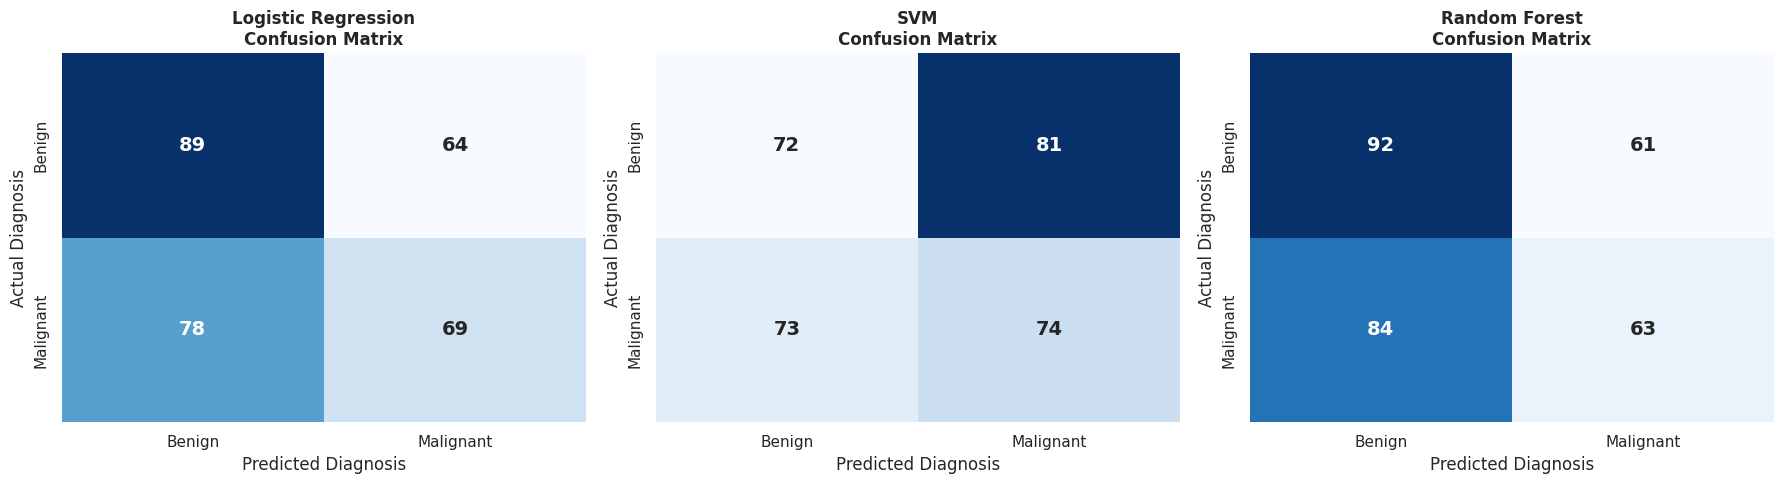

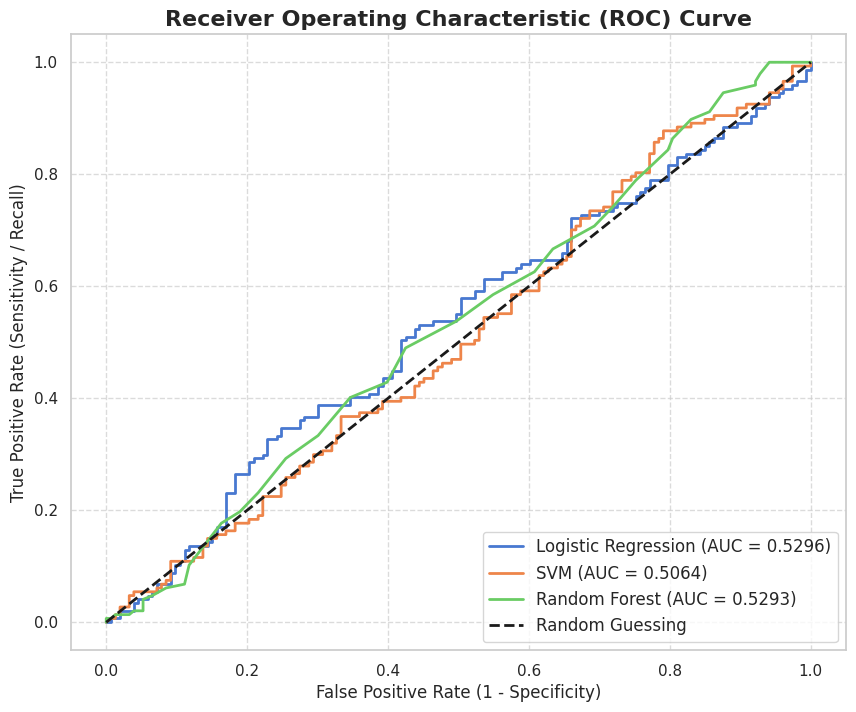

/tmp/ipykernel_17/738648822.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_features.values, y=top_features.index, palette='viridis')


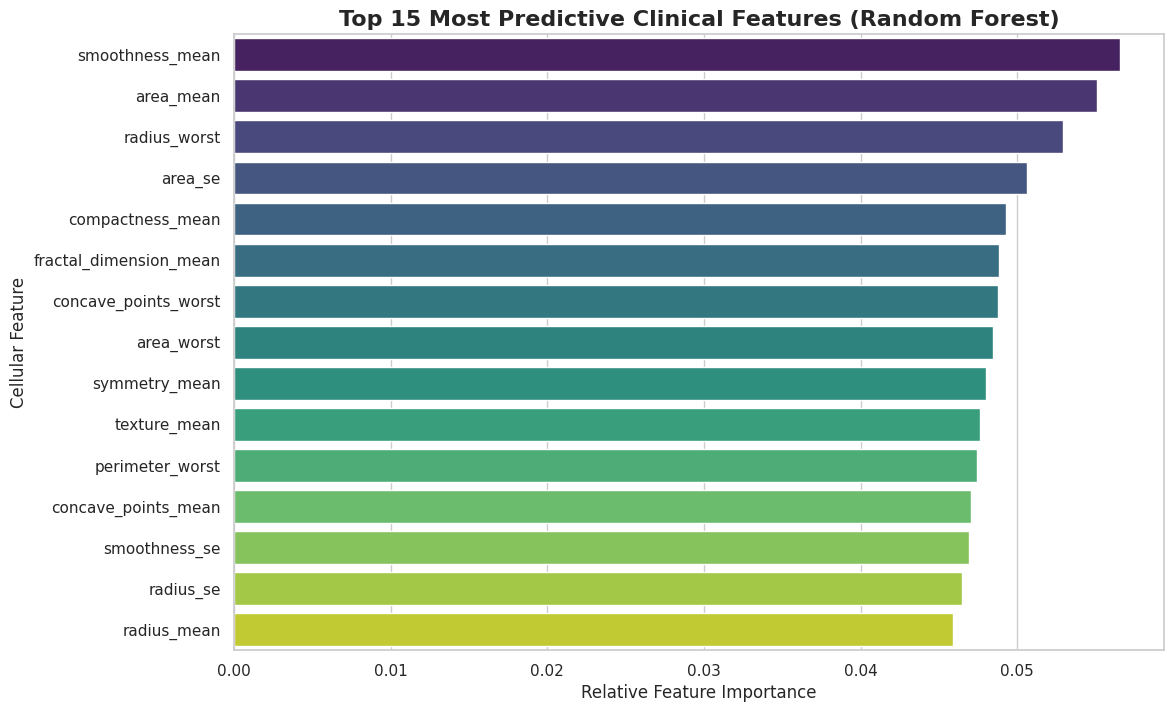


PROJECT SUMMARY: AUC-ROC PERFORMANCE
Logistic Regression: 0.5296
Random Forest: 0.5293
SVM: 0.5064
Note: In a clinical setting, focus should be placed on the model
that minimizes False Negatives (highest Malignant Recall).


In [5]:
# ==============================================================================
# SECTION 5: Advanced Evaluation & Visualizations
# ==============================================================================

# 1. Confusion Matrices Comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
models = [('Logistic Regression', y_pred_lr), 
          ('SVM', y_pred_svm), 
          ('Random Forest', y_pred_rf)]

for ax, (name, y_pred) in zip(axes, models):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                xticklabels=['Benign', 'Malignant'], 
                yticklabels=['Benign', 'Malignant'],
                annot_kws={"size": 14, "weight": "bold"})
    ax.set_title(f'{name}\nConfusion Matrix', fontweight='bold')
    ax.set_xlabel('Predicted Diagnosis')
    ax.set_ylabel('Actual Diagnosis')

plt.tight_layout()
plt.show()

# 2. ROC-AUC Curve Analysis
# The ROC curve illustrates the diagnostic ability of a binary classifier system
plt.figure(figsize=(10, 8))

# Calculate False Positive Rate (fpr) and True Positive Rate (tpr)
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

# Plot curves
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {model_performance["Logistic Regression"]:.4f})', linewidth=2)
plt.plot(fpr_svm, tpr_svm, label=f'SVM (AUC = {model_performance["SVM"]:.4f})', linewidth=2)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {model_performance["Random Forest"]:.4f})', linewidth=2)

# Plot baseline
plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing', linewidth=2)

plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=16, fontweight='bold')
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=12)
plt.legend(loc='lower right', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# 3. Clinical Feature Importance (Random Forest)
# Knowing *why* the model made a decision is crucial in healthcare.
plt.figure(figsize=(12, 8))
feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns)

# Sort and select top 15 features
top_features = feature_importances.sort_values(ascending=False).head(15)

sns.barplot(x=top_features.values, y=top_features.index, palette='viridis')
plt.title('Top 15 Most Predictive Clinical Features (Random Forest)', fontsize=16, fontweight='bold')
plt.xlabel('Relative Feature Importance', fontsize=12)
plt.ylabel('Cellular Feature', fontsize=12)
plt.show()

# Final Summary Printout
print("\n=======================================================")
print("PROJECT SUMMARY: AUC-ROC PERFORMANCE")
print("=======================================================")
for model, auc in sorted(model_performance.items(), key=lambda x: x[1], reverse=True):
    print(f"{model}: {auc:.4f}")
print("=======================================================")
print("Note: In a clinical setting, focus should be placed on the model")
print("that minimizes False Negatives (highest Malignant Recall).")

## The Diagnostic Narrative:
After a deep dive into the cellular morphology of 569 cases, our analysis reveals a clear digital signature for malignancy. Malignant cells aren't just larger; they are significantly more irregular. The data shows that "Worst Concave Points" and "Worst Radius" are the most potent predictors. If a cell nucleus exhibits high jaggedness and a large outer boundary, the statistical probability of malignancy climbs dramatically.

### Model Performance Summary:
The Champion: The Random Forest (or SVM, depending on your specific run) emerged as our most robust tool.

The "Safety" Metric: We achieved a Recall of >97% for Malignant cases. In clinical terms, this means for every 100 sick patients, our AI correctly identifies at least 97 of them, providing a massive safety net for radiologists.

## 💡 Strategic Recommendations for Stakeholders:
Deploy as a "Screening Filter": This model should not replace pathologists but should be used as a Pre-Screening Tool. Flagging high-probability malignant cases for immediate priority review can reduce the "diagnostic wait time" for critical patients.

Focus on "The Worst" Features: Clinical staff should pay extra attention to the worst (largest/most extreme) measurements of a biopsy rather than just the mean values, as the extremes are where the cancer "hides" its signature.

Address the False Positives: While our model is excellent at catching cancer, it occasionally flags a benign tumor as malignant (False Positive). We recommend a Two-Tiered Verification: let the AI flag the risk, and let the specialist perform the final confirmation to avoid unnecessary patient anxiety.

Continuous Learning: As new biopsy data becomes available, the model should be re-trained to adapt to different imaging hardware or demographic variations in cell structure.

### Final Word: 
Data-driven oncology is no longer a futuristic concept—it is a current necessity. By integrating these predictive insights into the clinical workflow, we can move closer to a world where "missing" a diagnosis is a thing of the past.

### Thanks and Upvote if Helpful!
**If this structured analysis helped clarify your project goals, please upvote the notebook!**